# Notebook 02 — MDP Environment

Illustrates the storage dynamics (eqs. 2–4) and reward function (eq. 5) from §2.1 of Löhndorf & Minner (2009).

**Goals:**
- Show how charging $c^+$ and discharging $c^-$ depend on the bid $x$, supply $y'$, and storage level $g$.
- Plot the reward surface $r(S, x, S')$ as a function of bid and supply for different storage levels.
- Demonstrate the effect of imbalance price factors $u$ and $o$.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from environment import EnvParams, storage_dynamics, reward

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## 1. Storage dynamics

Fix $g = 2$, $C = 4$, $\eta^+ = \eta^- = 1$ and vary bid $x$ and realised supply $y'$.

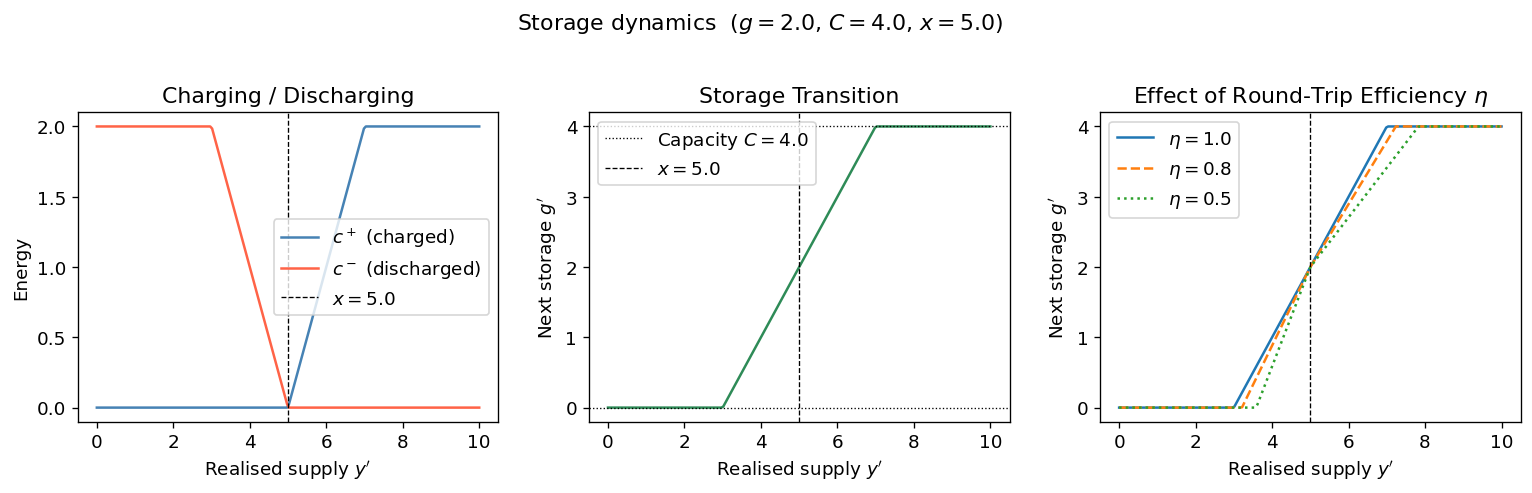

In [2]:
env = EnvParams(C=4.0, eta_plus=1.0, eta_minus=1.0, u=1.0, o=0.0, gamma=0.9)

g = 2.0
y_vals = np.linspace(0, 10, 200)
x_fixed = 5.0  # fixed bid

c_plus_arr, c_minus_arr, g_next_arr = [], [], []
for y_next in y_vals:
    cp, cm, gp = storage_dynamics(y_next, x_fixed, g, env)
    c_plus_arr.append(cp)
    c_minus_arr.append(cm)
    g_next_arr.append(gp)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(y_vals, c_plus_arr, color='steelblue', label='$c^+$ (charged)')
axes[0].plot(y_vals, c_minus_arr, color='tomato', label='$c^-$ (discharged)')
axes[0].axvline(x_fixed, color='k', ls='--', lw=0.8, label=f'$x={x_fixed}$')
axes[0].set_xlabel("Realised supply $y'$")
axes[0].set_ylabel('Energy')
axes[0].set_title('Charging / Discharging')
axes[0].legend()

axes[1].plot(y_vals, g_next_arr, color='seagreen')
axes[1].axhline(env.C, color='k', ls=':', lw=0.8, label=f'Capacity $C={env.C}$')
axes[1].axhline(0, color='k', ls=':', lw=0.8)
axes[1].axvline(x_fixed, color='k', ls='--', lw=0.8, label=f'$x={x_fixed}$')
axes[1].set_xlabel("Realised supply $y'$")
axes[1].set_ylabel("Next storage $g'$")
axes[1].set_title('Storage Transition')
axes[1].legend()

# Effect of storage efficiency
for eta, ls in [(1.0, '-'), (0.8, '--'), (0.5, ':')]:
    env_eta = EnvParams(C=4.0, eta_plus=np.sqrt(eta), eta_minus=np.sqrt(eta))
    gp_eta = [storage_dynamics(yp, x_fixed, g, env_eta)[2] for yp in y_vals]
    axes[2].plot(y_vals, gp_eta, ls=ls, label=f'$\\eta={eta}$')
axes[2].axvline(x_fixed, color='k', ls='--', lw=0.8)
axes[2].set_xlabel("Realised supply $y'$")
axes[2].set_ylabel("Next storage $g'$")
axes[2].set_title('Effect of Round-Trip Efficiency $\\eta$')
axes[2].legend()

plt.suptitle(f'Storage dynamics  ($g={g}$, $C={env.C}$, $x={x_fixed}$)', y=1.02)
plt.tight_layout()
plt.show()

## 2. Reward surface

Fix price $p' = 5$ and storage $g = 0$, then plot $r(S, x, S')$ as a function of bid $x$ and supply $y'$.

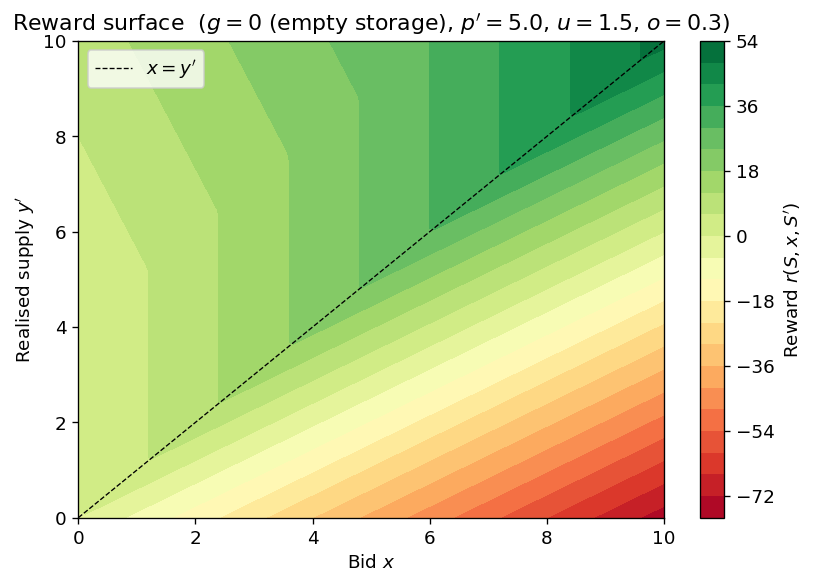

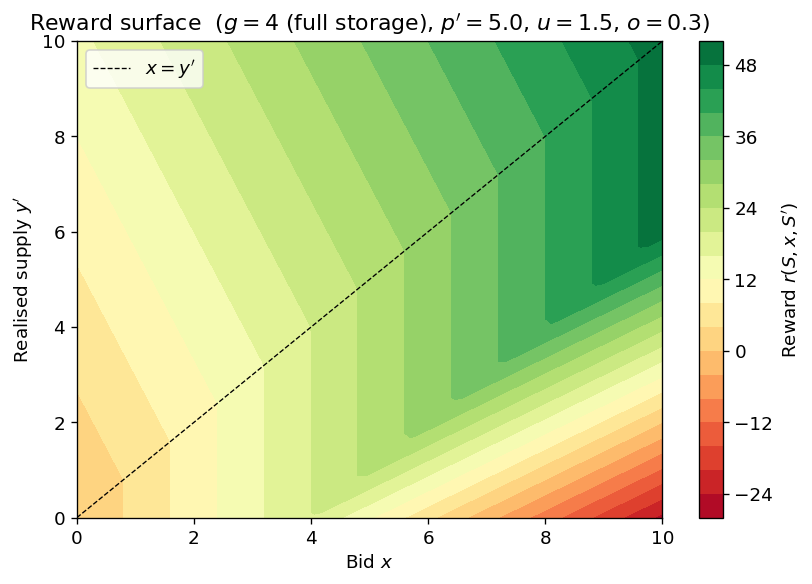

In [3]:
env = EnvParams(C=4.0, eta_plus=1.0, eta_minus=1.0, u=1.5, o=0.3, gamma=0.9)
p_next = 5.0

x_grid = np.linspace(0, 10, 80)
y_grid = np.linspace(0, 10, 80)
XX, YY = np.meshgrid(x_grid, y_grid)

for g_fixed, title in [(0.0, '$g=0$ (empty storage)'), (4.0, '$g=4$ (full storage)')]:
    R = np.zeros_like(XX)
    for i in range(len(y_grid)):
        for j in range(len(x_grid)):
            y_next = YY[i, j]
            x = XX[i, j]
            cp, cm, _ = storage_dynamics(y_next, x, g_fixed, env)
            R[i, j] = reward(y_next, p_next, x, cp, cm, env)

    fig, ax = plt.subplots(figsize=(7, 5))
    cf = ax.contourf(XX, YY, R, levels=20, cmap='RdYlGn')
    plt.colorbar(cf, ax=ax, label='Reward $r(S,x,S\')$')
    ax.plot([0, 10], [0, 10], 'k--', lw=0.8, label='$x = y\'' + '$')
    ax.set_xlabel("Bid $x$")
    ax.set_ylabel("Realised supply $y'$")
    ax.set_title(f'Reward surface  ({title}, $p\'={p_next}$, $u={env.u}$, $o={env.o}$)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 3. Optimal myopic bid (no storage, no future)

With $\gamma = 0$ and $C = 0$, the optimal bid is simply the expected supply $\mu_Y$, since
imbalance costs are symmetric when $u = 1$ and $o = 0$. For $u > 1$, the optimal bid shifts
below the mean to reduce costly shortfalls.

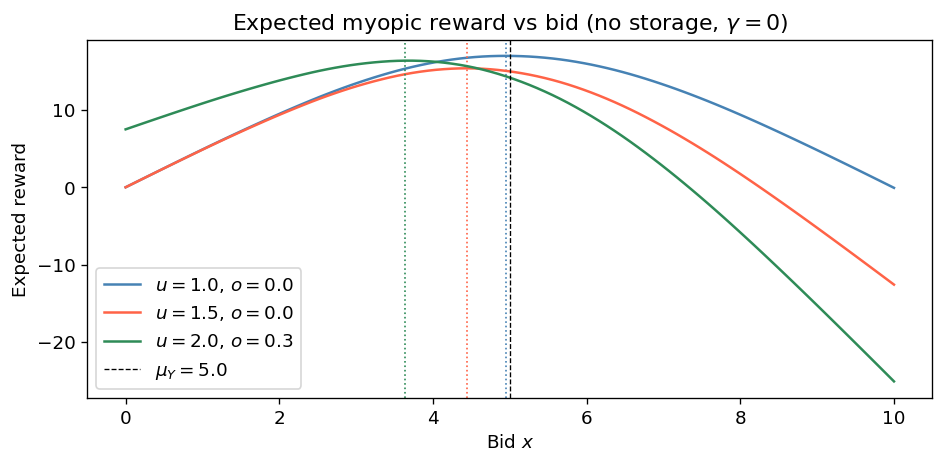

In [4]:
from stochastic import StochasticParams, step as ar_step

def expected_reward_no_storage(x, mu_Y, sigma_Y, p_next, u, o, n=5000, seed=0):
    rng = np.random.default_rng(seed)
    env0 = EnvParams(C=0.0, eta_plus=1.0, eta_minus=1.0, u=u, o=o, gamma=0.0)
    y_samples = rng.normal(mu_Y, sigma_Y, n)
    rewards = []
    for y_next in y_samples:
        y_next = max(y_next, 0.0)
        cp, cm, _ = storage_dynamics(y_next, x, 0.0, env0)
        rewards.append(reward(y_next, p_next, x, cp, cm, env0))
    return np.mean(rewards)

x_range = np.linspace(0, 10, 100)
mu_Y, sigma_Y, p_next = 5.0, 2.0, 5.0

fig, ax = plt.subplots(figsize=(8, 4))
for u_val, o_val, color in [(1.0, 0.0, 'steelblue'), (1.5, 0.0, 'tomato'), (2.0, 0.3, 'seagreen')]:
    er = [expected_reward_no_storage(x, mu_Y, sigma_Y, p_next, u_val, o_val) for x in x_range]
    ax.plot(x_range, er, color=color, label=f'$u={u_val}$, $o={o_val}$')
    opt_x = x_range[np.argmax(er)]
    ax.axvline(opt_x, color=color, ls=':', lw=1)

ax.axvline(mu_Y, color='k', ls='--', lw=0.8, label=f'$\\mu_Y={mu_Y}$')
ax.set_xlabel('Bid $x$')
ax.set_ylabel('Expected reward')
ax.set_title('Expected myopic reward vs bid (no storage, $\\gamma=0$)')
ax.legend()
plt.tight_layout()
plt.show()